In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [2]:
path = '../target_selection/photom_redshift_distribution/'
config_survey_dark = {'survey_type': 'Dark',
                 'N_fibres': 30000,
                'S_FoV': 3,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [ path+f'COSMOS_QSO_WST_QSO_no_H.npz', 
                                        path+f'COSMOS_LBG_udropout_highz.npz', 
                                        path+f'COSMOS_LBG_gdropout.npz',
                                        path+f'COSMOS_LBG_rdropout.npz'],
                 'tracers' : ['QSO', 'LBGu', 'LBGg','LBGr'],
                    'color' : ['k', 'm', 'g', 'r']}
config_dark_update = _survey_design_telescope_metrics.Survey_design_telescope_metrics(config_survey_dark, max_mag=None)   

In [3]:
res = _survey_design_science_metrics.Survey_design_science_metrics(config_dark_update, cosmo, 
                                                                   redshift_eval_range =[
                                                                       [0, 4], [2, 4.5], [2.5, 5], [4, 6]], 
                                                                   mag_max_eval_range=[[23, 24.5], [24.2, 26], [24.2, 26], [24.2, 26]])

Computing forecasts: Survey  Dark  --- tracer:  QSO
Computing forecasts: Survey  Dark  --- tracer:  LBGu
Computing forecasts: Survey  Dark  --- tracer:  LBGg
Computing forecasts: Survey  Dark  --- tracer:  LBGr


(22.5, 26.0)

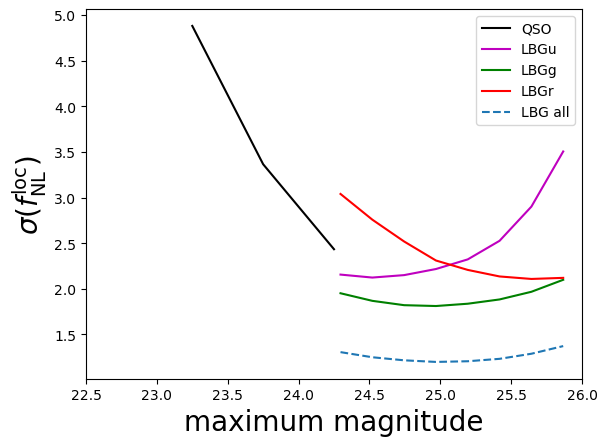

In [4]:
for i,tracer in enumerate(config_dark_update['tracers']):
    
    plt.plot(res[tracer+'_mag_max_eval'], res[tracer+'_sigma_fnl_eff'] , color = config_dark_update['color'][i], label = tracer)

err_tot_2 = [1/np.array(res[tracer+'_sigma_fnl_eff'])**2 for tracer in ['LBGu', 'LBGg', 'LBGr'] ]
plt.plot(res['LBGr_mag_max_eval'], np.sum(err_tot_2, axis=0)**(-.5), '--', label = 'LBG all')
plt.legend()
plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
plt.xlabel('maximum magnitude', fontsize=20)
plt.xlim(22.5, 26)

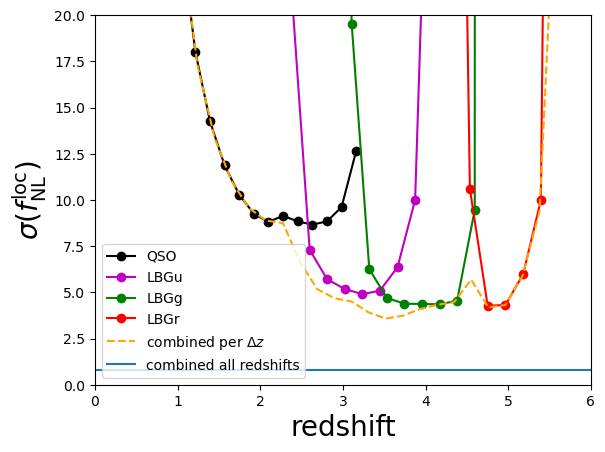

In [6]:
for i,tracer in enumerate(config_dark_update['tracers']):
    
    plt.plot(res[tracer+'_list_zbin_fnl'][2], res[tracer+'_list_sigma_fnl'][2], '-o',  color = config_dark_update['color'][i], label = tracer)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.xlabel('redshift', fontsize=20)
    plt.xlim(0, 6)
    plt.ylim(0, 20)
z = np.linspace(0, 6, 30)
y = [np.interp(z, res[tracer+'_list_zbin_fnl'][2], 1/(np.array(res[tracer+'_list_sigma_fnl'][2])**2), left=0.000000000000001, right=0.0000000000001) for tracer in config_dark_update['tracers']]
plt.plot(z, np.sum(y, axis=0)**(-0.5), 'orange', ls='--', label = r'combined per $\Delta z$')
all = np.sum(np.sum(y, axis=0))
plt.axhline(all, label = 'combined all redshifts')
plt.legend()